## LSTM Model Implementation

In [2]:
# Downloading and prepare price data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tickers = ['KO', 'PEP']
prices = yf.download(tickers, start='2005-01-01', auto_adjust=False)['Adj Close']
prices.columns = ['KO', 'PEP']
prices = prices.dropna()

print(prices.head())
print(prices.tail())

[*********************100%***********************]  2 of 2 completed

                   KO        PEP
Date                            
2005-01-03  10.941303  28.442074
2005-01-04  10.788537  28.239458
2005-01-05  10.738494  28.272322
2005-01-06  10.828048  28.474924
2005-01-07  10.841213  28.721348
                   KO         PEP
Date                             
2026-04-17  75.739998  157.669998
2026-04-20  75.480003  156.990005
2026-04-21  74.699997  154.919998
2026-04-22  74.629997  153.789993
2026-04-23  76.533501  156.039993


In [3]:
# Convert prices to returns

returns = prices.pct_change().dropna()

print(returns.head())

                  KO       PEP
Date                          
2005-01-04 -0.013962 -0.007124
2005-01-05 -0.004639  0.001164
2005-01-06  0.008340  0.007166
2005-01-07  0.001216  0.008654
2005-01-10  0.005588  0.024976


In [4]:
# Train-test split

train_size = int(len(returns) * 0.8)

train_returns = returns.iloc[:train_size]
test_returns = returns.iloc[train_size:]

print("Train shape:", train_returns.shape)
print("Test shape:", test_returns.shape)

Train shape: (4287, 2)
Test shape: (1072, 2)


In [5]:
# Scale returns

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_returns)
test_scaled = scaler.transform(test_returns)

In [6]:
# Create sequences

def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lookback = 30

X_train, y_train = create_sequences(train_scaled, lookback)
X_test, y_test = create_sequences(test_scaled, lookback)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4257, 30, 2)
y_train shape: (4257, 2)
X_test shape: (1042, 30, 2)
y_test shape: (1042, 2)


In [7]:
# Building the LSTM model

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, 2)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(2)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

C:\Users\engr_\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,322 (204.38 KB)

 Trainable params: 52,322 (204.38 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.0124 - val_loss: 0.0021
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0035 - val_loss: 0.0024
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0032 - val_loss: 0.0022
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0029 - val_loss: 0.0022
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0028 - val_loss: 0.0021
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 8/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 9/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 10/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 11/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 12/100
134/134 ━━━━━━━━

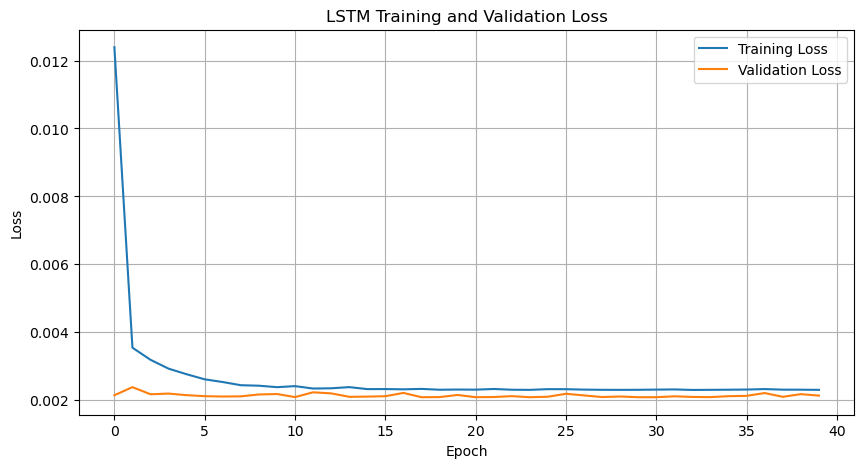

In [9]:
# Plotting training & validation loss

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Testing predictions based on returns

y_pred_scaled = model.predict(X_test)

y_test_returns = scaler.inverse_transform(y_test)
y_pred_returns = scaler.inverse_transform(y_pred_scaled)

pred_returns_df = pd.DataFrame(
    y_pred_returns,
    columns=['KO_Pred_Return', 'PEP_Pred_Return'],
    index=test_returns.index[lookback:]
)

actual_returns_df = pd.DataFrame(
    y_test_returns,
    columns=['KO_Actual_Return', 'PEP_Actual_Return'],
    index=test_returns.index[lookback:]
)

returns_results = pd.concat([actual_returns_df, pred_returns_df], axis=1)
print(returns_results.head())

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
            KO_Actual_Return  PEP_Actual_Return  KO_Pred_Return  \
Date                                                              
2022-02-28         -0.009706          -0.027557       -0.000076   
2022-03-01         -0.004338          -0.008978       -0.000058   
2022-03-02          0.007423           0.013866       -0.000039   
2022-03-03          0.000641          -0.001070       -0.000061   
2022-03-04          0.001601           0.015189       -0.000067   

            PEP_Pred_Return  
Date                         
2022-02-28        -0.000014  
2022-03-01         0.000037  
2022-03-02         0.000079  
2022-03-03         0.000045  
2022-03-04         0.000027  


In [11]:
# Converting predicted returns back to prices for test evaluation

test_price_index = test_returns.index[lookback:]

ko_actual_prices = []
ko_pred_prices = []
pep_actual_prices = []
pep_pred_prices = []

for i, date in enumerate(test_price_index):

    prev_price_row = prices.shift(1).loc[date]

    ko_prev_price = prev_price_row['KO']
    pep_prev_price = prev_price_row['PEP']

    ko_actual_price = ko_prev_price * (1 + returns_results.loc[date, 'KO_Actual_Return'])
    ko_pred_price = ko_prev_price * (1 + returns_results.loc[date, 'KO_Pred_Return'])

    pep_actual_price = pep_prev_price * (1 + returns_results.loc[date, 'PEP_Actual_Return'])
    pep_pred_price = pep_prev_price * (1 + returns_results.loc[date, 'PEP_Pred_Return'])

    ko_actual_prices.append(ko_actual_price)
    ko_pred_prices.append(ko_pred_price)
    pep_actual_prices.append(pep_actual_price)
    pep_pred_prices.append(pep_pred_price)

price_results = pd.DataFrame({
    'KO_Actual': ko_actual_prices,
    'KO_Predicted': ko_pred_prices,
    'PEP_Actual': pep_actual_prices,
    'PEP_Predicted': pep_pred_prices
}, index=test_price_index)

print(price_results.head())

            KO_Actual  KO_Predicted  PEP_Actual  PEP_Predicted
Date                                                          
2022-02-28  54.859013     55.392466  143.161697     147.216508
2022-03-01  54.621033     54.855804  141.876434     143.167028
2022-03-02  55.026485     54.618886  143.843628     141.887688
2022-03-03  55.061745     55.023155  143.689651     143.850172
2022-03-04  55.149879     55.058037  145.872223     143.693499


In [12]:
# Evaluating performance

def evaluate_forecast(actual, predicted, stock_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    print(f"{stock_name} Performance:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")
    print()

evaluate_forecast(price_results['KO_Actual'], price_results['KO_Predicted'], 'KO')
evaluate_forecast(price_results['PEP_Actual'], price_results['PEP_Predicted'], 'PEP')

KO Performance:
MAE  : 0.4602
RMSE : 0.6250
MAPE : 0.75%

PEP Performance:
MAE  : 1.3230
RMSE : 1.7941
MAPE : 0.87%



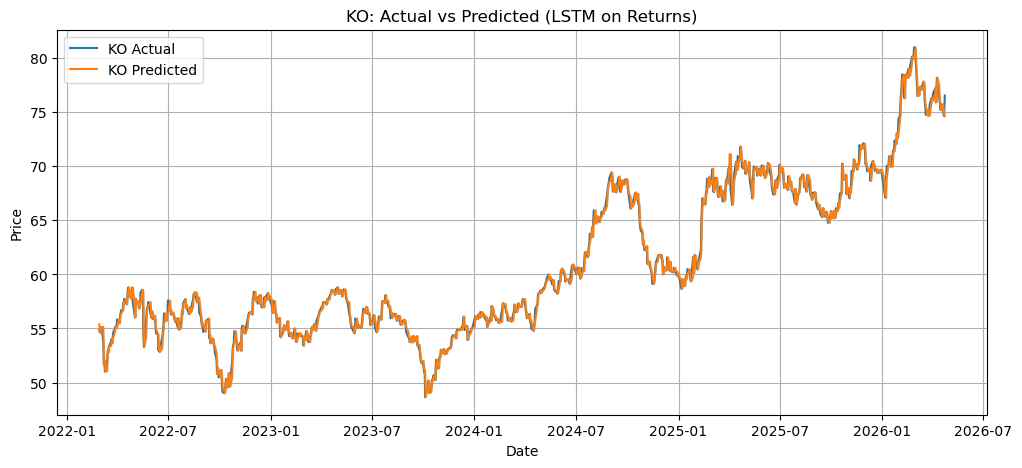

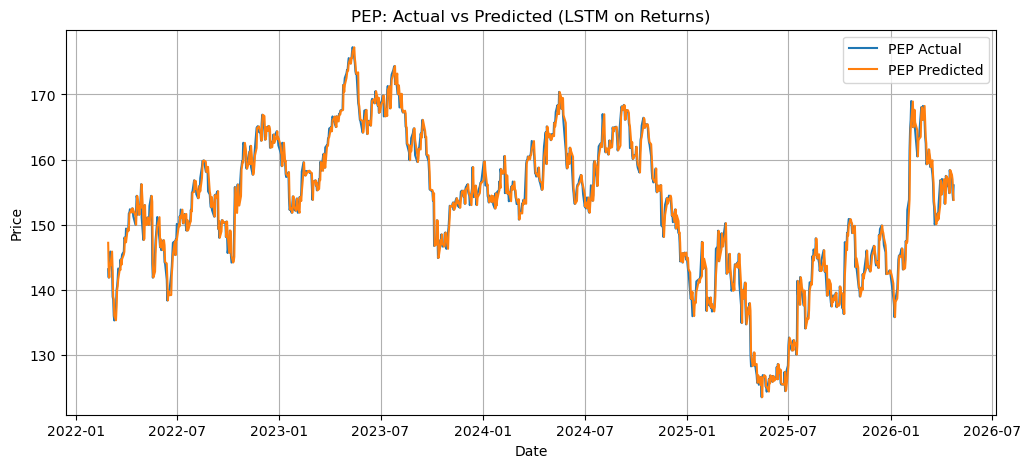

In [13]:
# Plotting actual vs predicted

plt.figure(figsize=(12, 5))
plt.plot(price_results.index, price_results['KO_Actual'], label='KO Actual')
plt.plot(price_results.index, price_results['KO_Predicted'], label='KO Predicted')
plt.title('KO: Actual vs Predicted (LSTM on Returns)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(price_results.index, price_results['PEP_Actual'], label='PEP Actual')
plt.plot(price_results.index, price_results['PEP_Predicted'], label='PEP Predicted')
plt.title('PEP: Actual vs Predicted (LSTM on Returns)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Forecast next 10 days

forecast_horizon = 10

full_scaled = scaler.transform(returns)
last_window = full_scaled[-lookback:].copy()

future_returns_scaled = []

for _ in range(forecast_horizon):
    x_input = last_window.reshape(1, lookback, 2)
    next_pred_scaled = model.predict(x_input, verbose=0)[0]
    future_returns_scaled.append(next_pred_scaled)
    last_window = np.vstack([last_window[1:], next_pred_scaled])

future_returns_scaled = np.array(future_returns_scaled)
future_returns = scaler.inverse_transform(future_returns_scaled)

future_returns_df = pd.DataFrame(
    future_returns,
    columns=['KO_Return_Forecast', 'PEP_Return_Forecast']
)

print(future_returns_df)

   KO_Return_Forecast  PEP_Return_Forecast
0           -0.000001            -0.000012
1           -0.000032            -0.000024
2           -0.000044            -0.000026
3           -0.000046            -0.000024
4           -0.000044            -0.000021
5           -0.000040            -0.000019
6           -0.000036            -0.000017
7           -0.000032            -0.000016
8           -0.000028            -0.000016
9           -0.000025            -0.000016


In [15]:
# Convert future returns to future prices

last_ko_price = prices['KO'].iloc[-1]
last_pep_price = prices['PEP'].iloc[-1]

ko_future_prices = []
pep_future_prices = []

ko_price = last_ko_price
pep_price = last_pep_price

for i in range(forecast_horizon):
    ko_price = ko_price * (1 + future_returns_df.loc[i, 'KO_Return_Forecast'])
    pep_price = pep_price * (1 + future_returns_df.loc[i, 'PEP_Return_Forecast'])

    ko_future_prices.append(ko_price)
    pep_future_prices.append(pep_price)

forecast_df = pd.DataFrame({
    'KO_Forecast': ko_future_prices,
    'PEP_Forecast': pep_future_prices
})

future_dates = pd.bdate_range(start=prices.index[-1] + pd.Timedelta(days=1), periods=forecast_horizon)
forecast_df.index = future_dates

print(forecast_df)

            KO_Forecast  PEP_Forecast
2026-04-24    76.533408    156.038157
2026-04-27    76.530981    156.034430
2026-04-28    76.527626    156.030383
2026-04-29    76.524070    156.026635
2026-04-30    76.520675    156.023335
2026-05-01    76.517589    156.020438
2026-05-04    76.514842    156.017802
2026-05-05    76.512412    156.015301
2026-05-06    76.510261    156.012825
2026-05-07    76.508348    156.010309


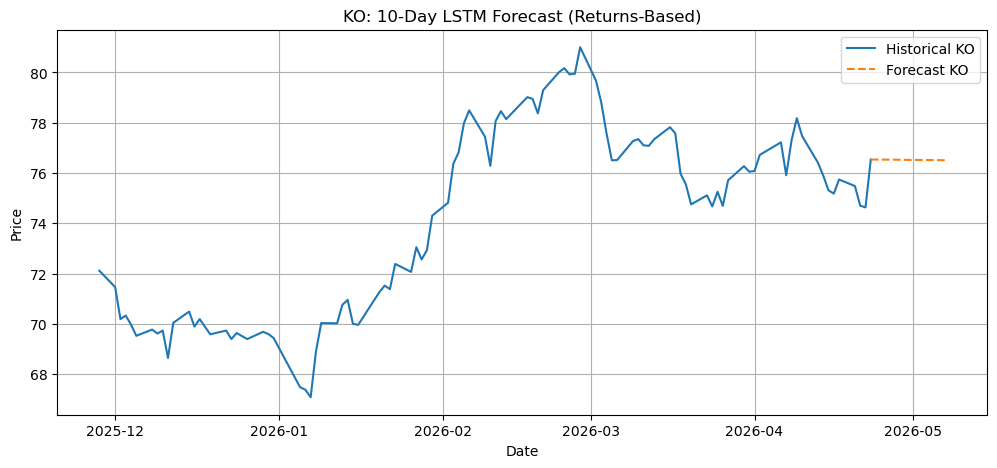

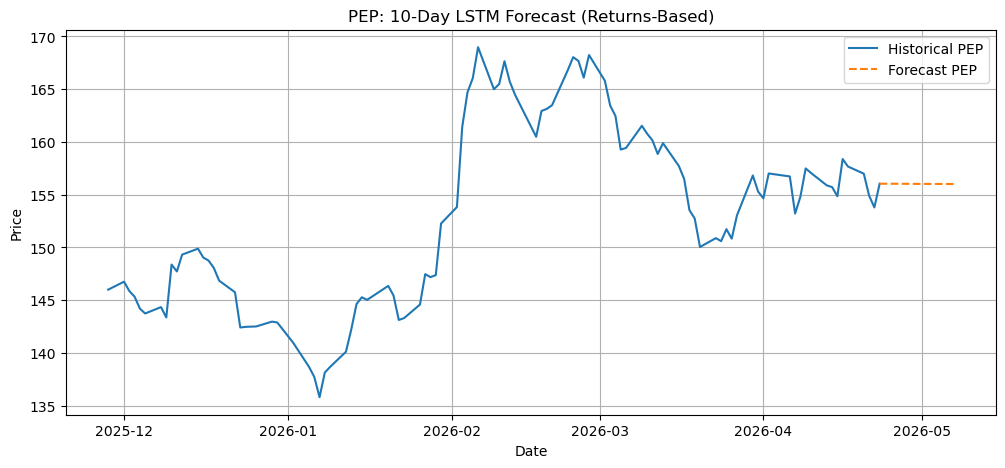

In [16]:
# Plot connected future forecast

plt.figure(figsize=(12, 5))
plt.plot(prices.index[-100:], prices['KO'].iloc[-100:], label='Historical KO')

ko_connected_dates = [prices.index[-1]] + list(forecast_df.index)
ko_connected_values = [prices['KO'].iloc[-1]] + list(forecast_df['KO_Forecast'])

plt.plot(ko_connected_dates, ko_connected_values, linestyle='--', label='Forecast KO')
plt.title('KO: 10-Day LSTM Forecast (Returns-Based)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(prices.index[-100:], prices['PEP'].iloc[-100:], label='Historical PEP')

pep_connected_dates = [prices.index[-1]] + list(forecast_df.index)
pep_connected_values = [prices['PEP'].iloc[-1]] + list(forecast_df['PEP_Forecast'])

plt.plot(pep_connected_dates, pep_connected_values, linestyle='--', label='Forecast PEP')
plt.title('PEP: 10-Day LSTM Forecast (Returns-Based)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

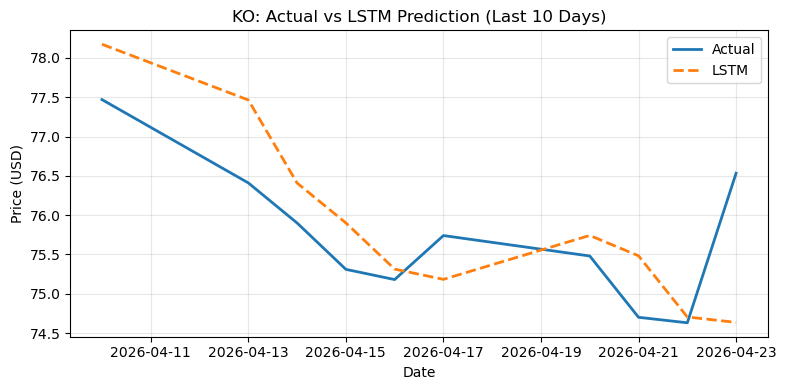

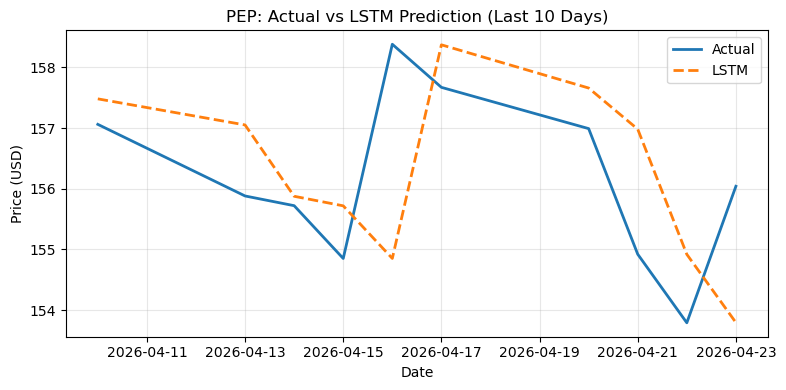

In [37]:
import matplotlib.pyplot as plt

# Select last 10 days
window = 10
lstm_subset = price_results.tail(window)

# ---------------------------
# KO plot
# ---------------------------
plt.figure(figsize=(8,4))
plt.plot(
    lstm_subset.index,
    lstm_subset['KO_Actual'],
    label='Actual',
    linewidth=2
)
plt.plot(
    lstm_subset.index,
    lstm_subset['KO_Predicted'],
    label='LSTM',
    linestyle='--',
    linewidth=2
)

plt.title('KO: Actual vs LSTM Prediction (Last 10 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# PEP plot
# ---------------------------
plt.figure(figsize=(8,4))
plt.plot(
    lstm_subset.index,
    lstm_subset['PEP_Actual'],
    label='Actual',
    linewidth=2
)
plt.plot(
    lstm_subset.index,
    lstm_subset['PEP_Predicted'],
    label='LSTM',
    linestyle='--',
    linewidth=2
)

plt.title('PEP: Actual vs LSTM Prediction (Last 10 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

END